In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
mdata_path = Path("/g/stegle/aalsayah/repos/data/slidatag/slidetags/mudata")

In [3]:
mdata = md.read(mdata_path / "SCP2170.h5mu")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


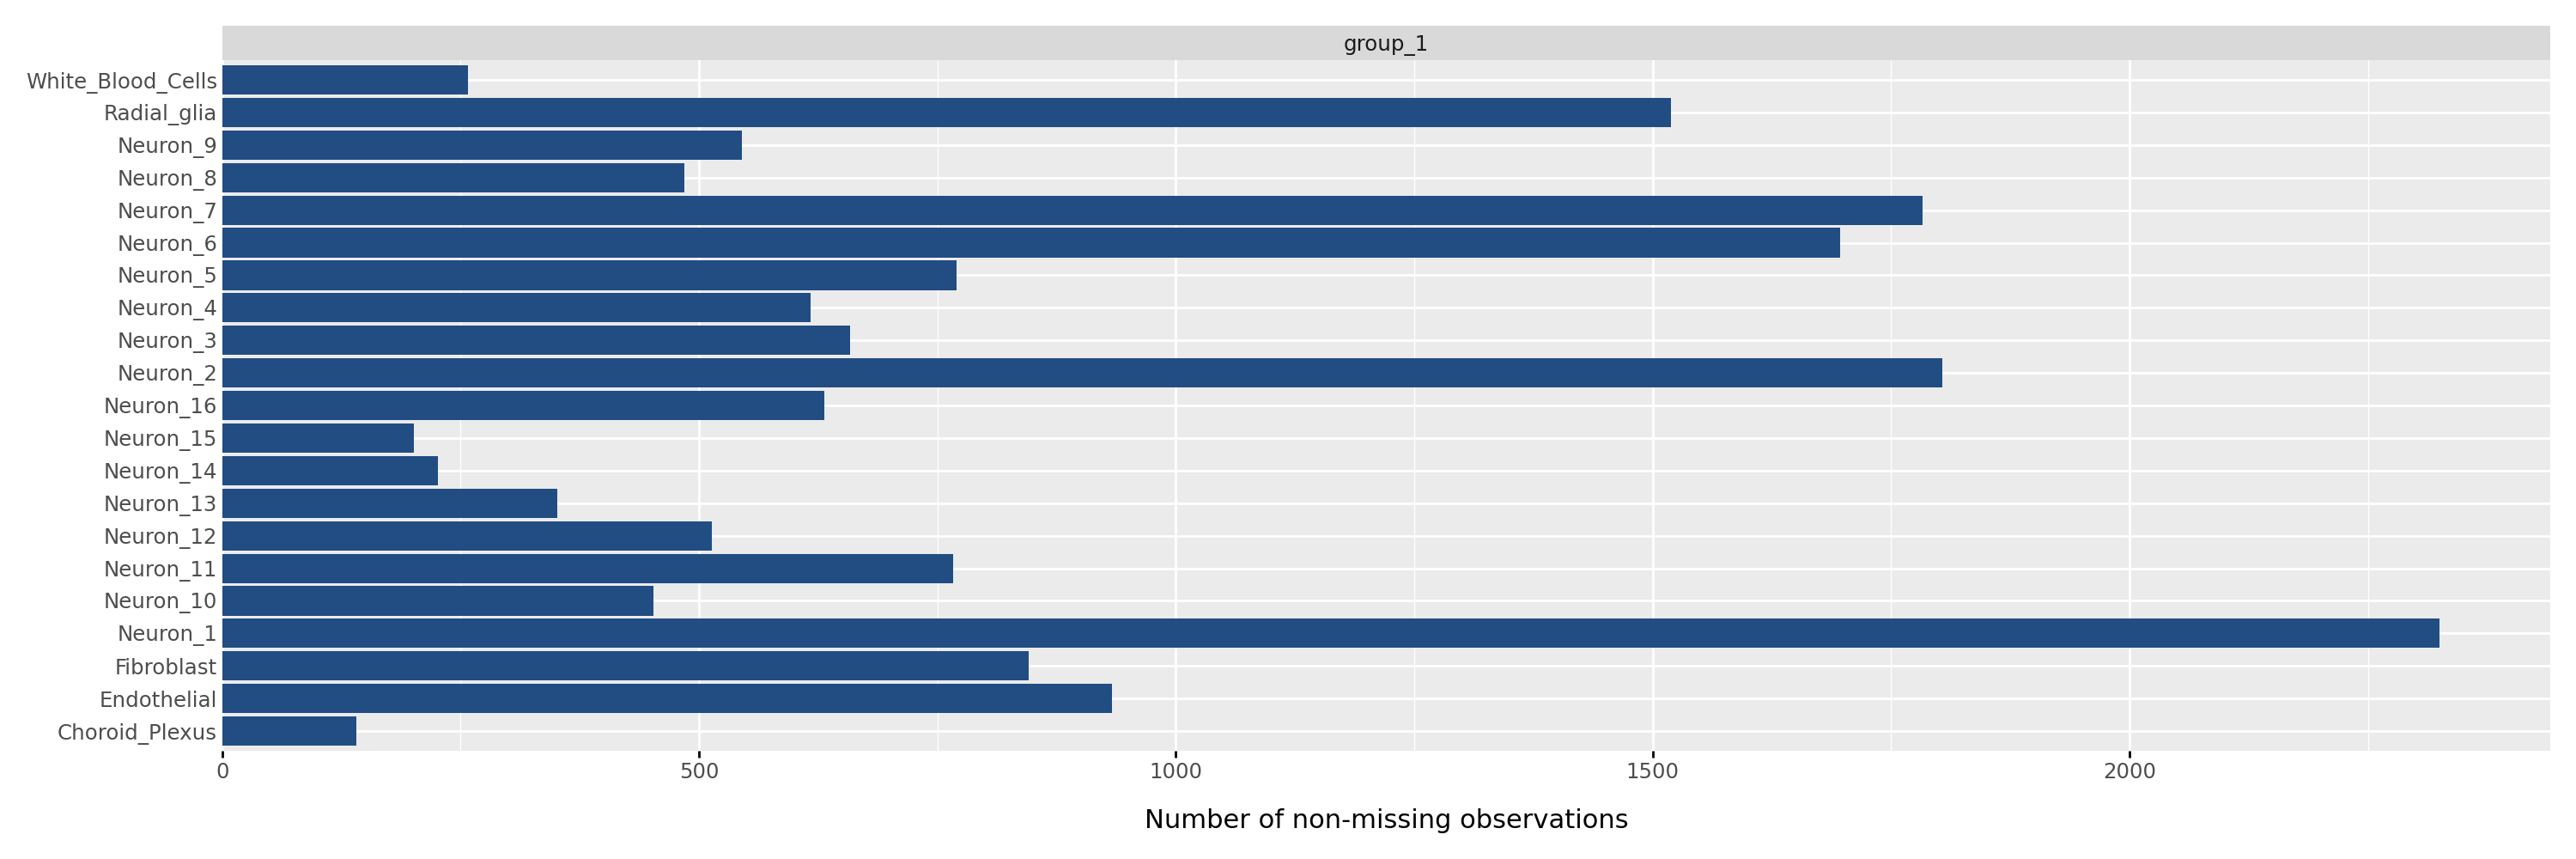

WARNING	Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site

  0%|                                                                                      | 0/1000 [00:00<?, …

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/linear_operator/utils/interpolation.py:71: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/linear_operator/utils/interpolation.py:71: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:653.)
INFO	Training converged after 728 epochs.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_opti

In [5]:
model = mfl.MOFAFLEX(
    mdata,
    mfl.DataOptions(covariates_obsm_key="spatial"),
    mfl.ModelOptions(
        n_factors=15,
        factor_prior="GP",
        likelihoods="Normal",
        weight_prior="Normal",
    ),
    mfl.TrainingOptions(
        batch_size=2000,
        n_particles=10,
        lr=0.005,
        max_epochs=1000,
        save_path=str("/g/stegle/aalsayah/repos/data/slidatag/slidetags/models/SCP2170_GP_model.hdf5"),
        early_stopper_patience=50,
    ),
)

In [6]:
models_path = Path("/g/stegle/aalsayah/repos/data/slidatag/slidetags/models")

In [7]:
model= mfl.MOFAFLEX.load(models_path / 'SCP2170_GP_model.hdf5')

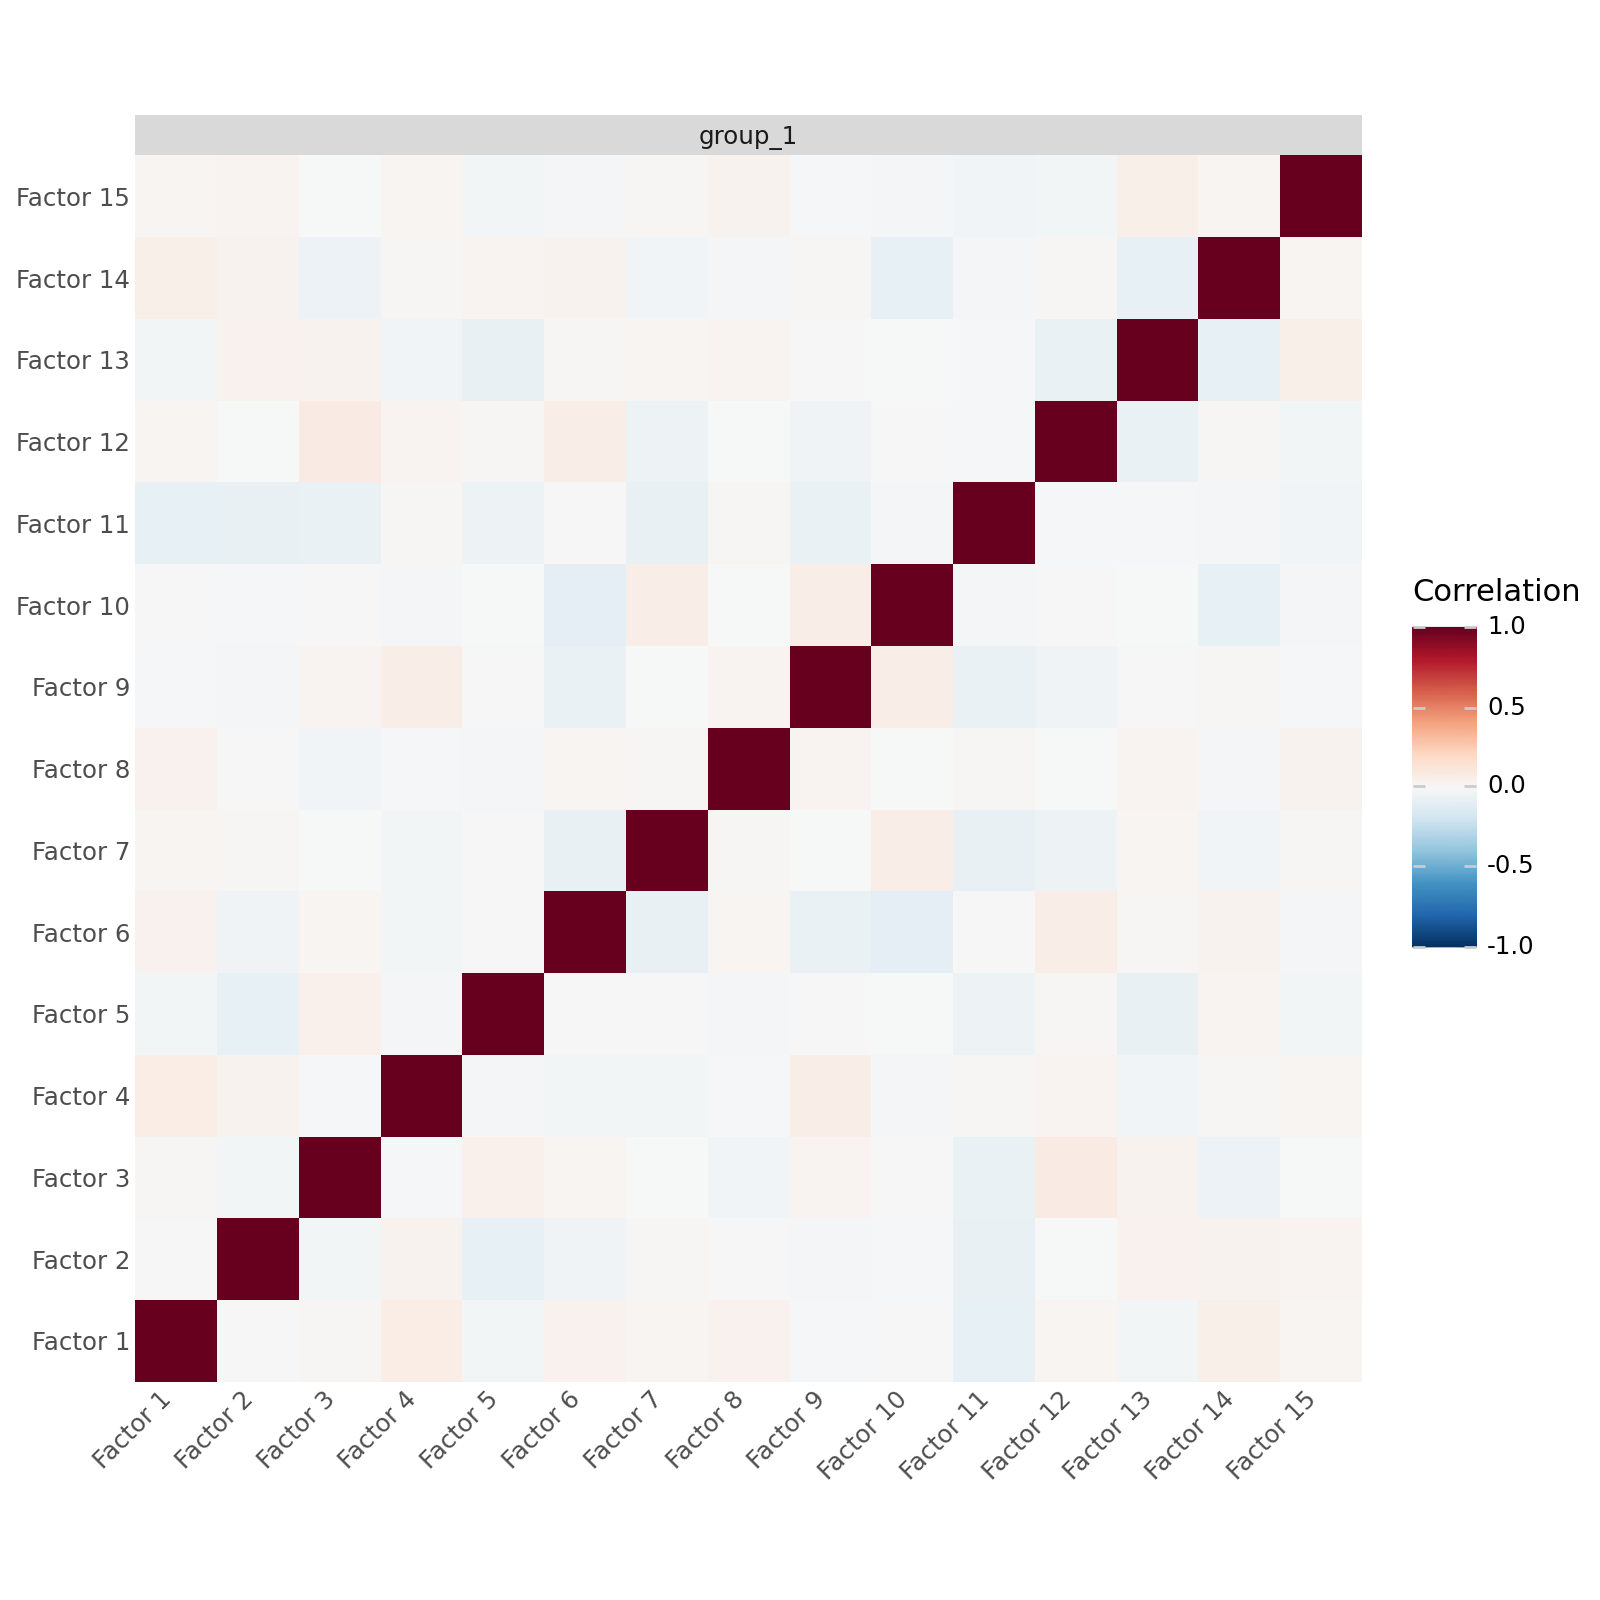

In [8]:
mfl.pl.factor_correlation(model)

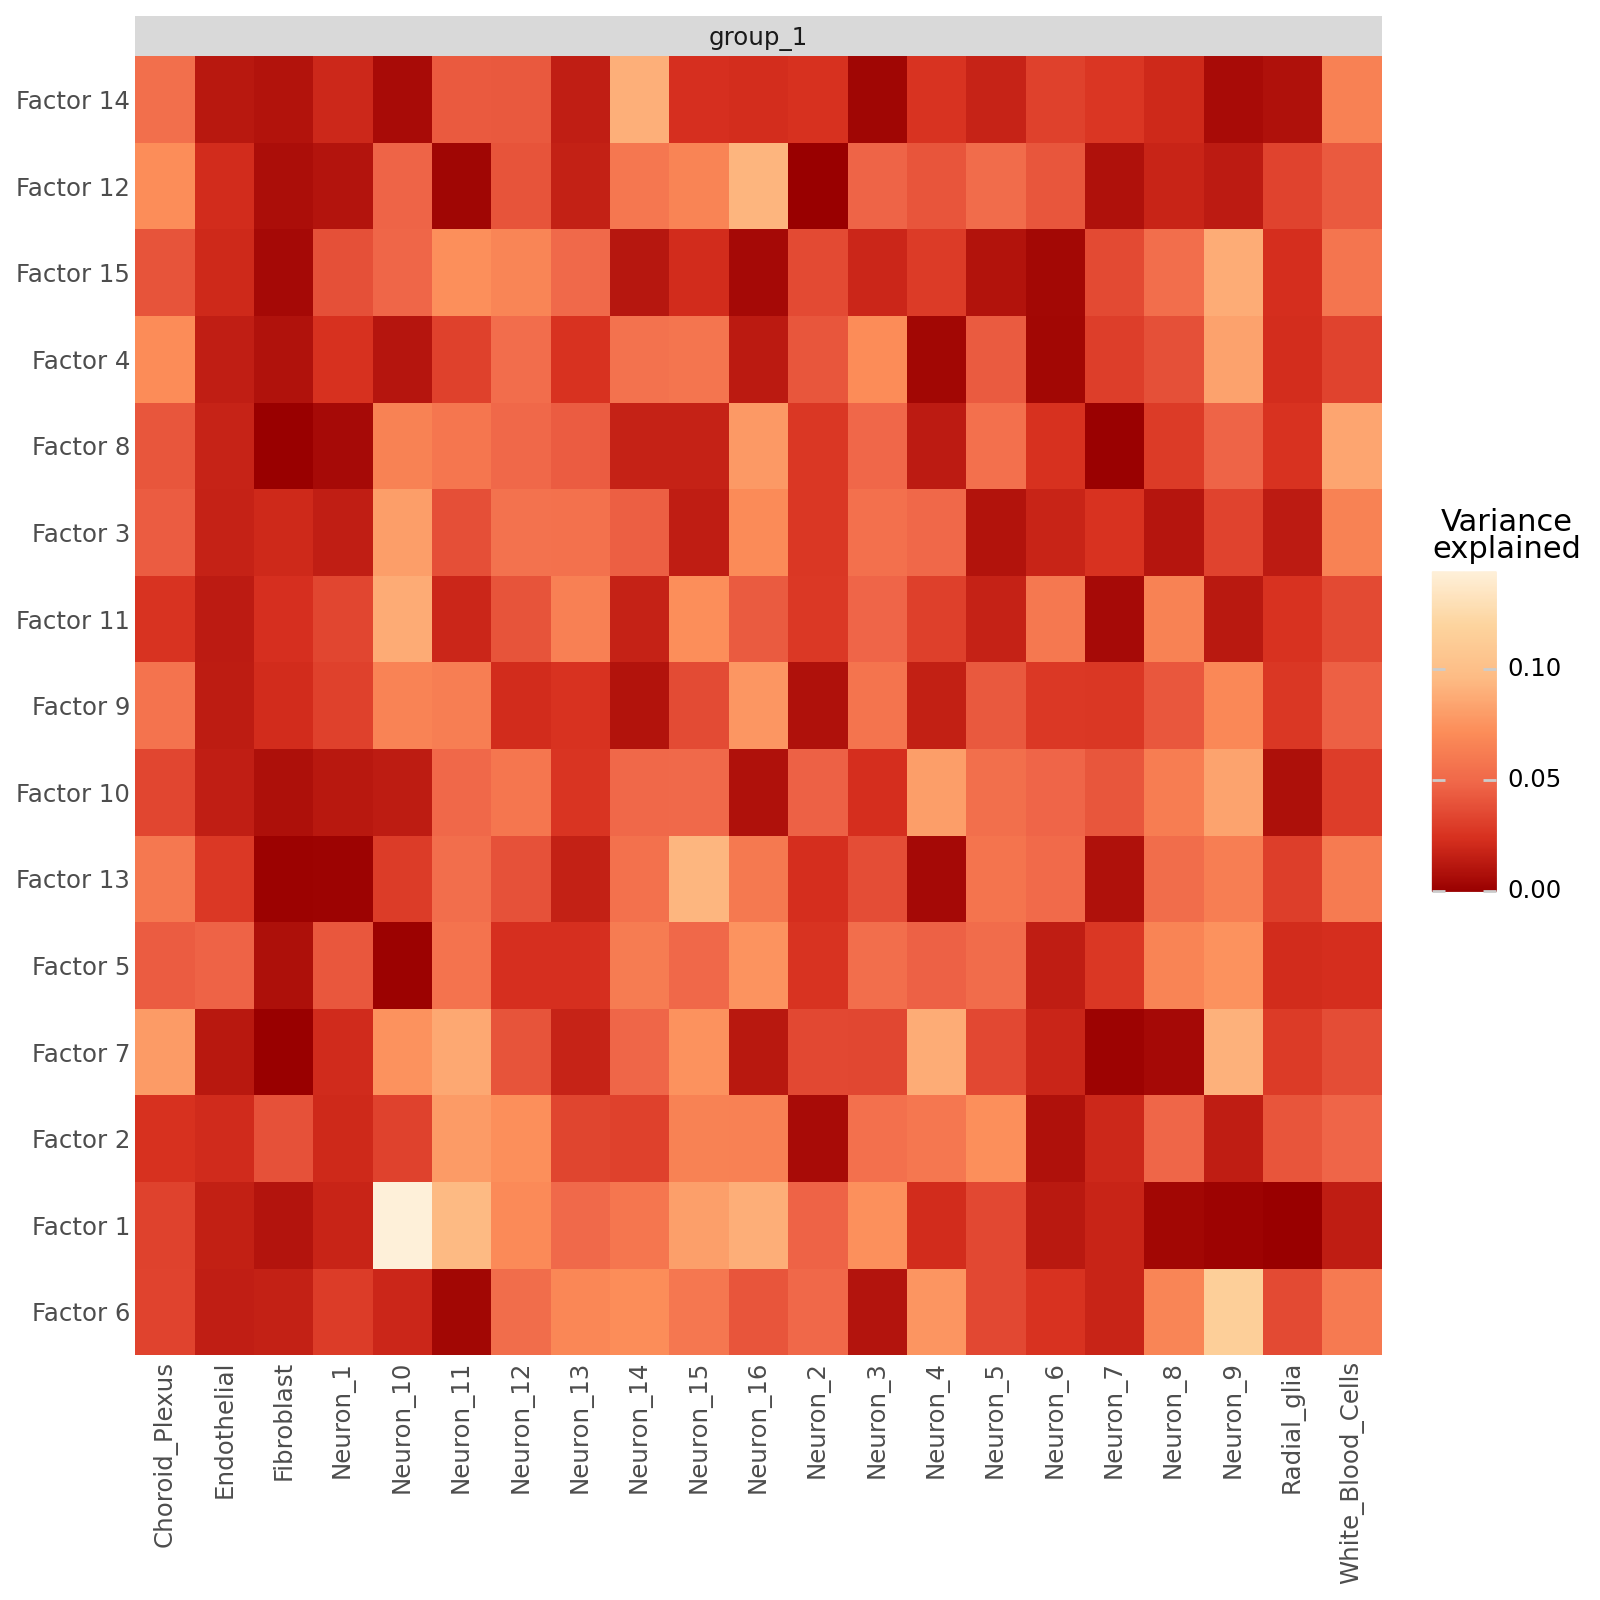

In [9]:
mfl.pl.variance_explained(model, figsize= (8,8))

In [10]:
print(model.get_r2(total=True))

                    group_1
Neuron_3           0.519844
Neuron_8           0.522596
Neuron_4           0.475803
Neuron_12          0.567219
Neuron_9           0.593047
Neuron_14          0.579643
Neuron_6           0.378242
Neuron_10          0.553066
Neuron_11          0.578781
Neuron_5           0.477963
Neuron_13          0.488773
Choroid_Plexus     0.628693
Neuron_16          0.586836
Neuron_2           0.386933
Radial_glia        0.329891
Neuron_1           0.326726
Endothelial        0.330399
Neuron_15          0.609062
Fibroblast         0.303683
White_Blood_Cells  0.692551
Neuron_7           0.311418


In [11]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

np.float64(0.48767471957584946)

In [12]:
weights_dict= model.get_weights()

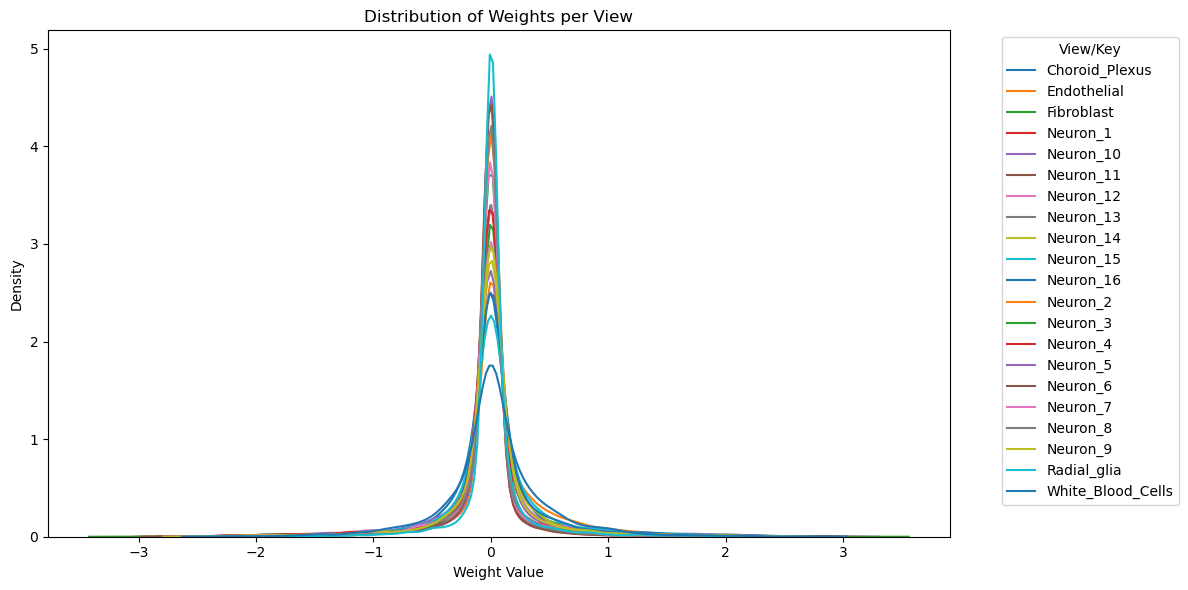

In [13]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
factors = model.get_factors()
factors = factors["group_1"]

In [15]:
data_path = Path("/g/stegle/aalsayah/repos/data/slidatag/slidetags/lrdata")
lrdata = sc.read_h5ad(data_path/ "SCP2170.h5ad")

In [16]:
lv1 = lrdata.obs["cell_type"]

In [17]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(4597,)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

In [19]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["cell_type"]

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()

#Filter out any datapoint in response var that is not in features
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

In [20]:
X = F.values
y = filtered_cell_types.values  # labels

In [21]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [22]:
print(X.shape, y.shape)

(4597, 15) (4597,)


In [23]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [25]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [26]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

In [27]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.32681159420289857

Classification Report:
                    precision    recall  f1-score   support

   Choroid Plexus       0.00      0.00      0.00        15
      Endothelial       0.20      0.43      0.28        23
       Fibroblast       0.28      0.30      0.29        66
         Neuron-1       0.51      0.48      0.49       179
        Neuron-10       0.33      0.45      0.38        44
        Neuron-11       0.22      0.35      0.27        43
        Neuron-12       0.18      0.28      0.22        43
        Neuron-13       0.21      0.37      0.27        30
        Neuron-14       0.07      0.15      0.10        27
        Neuron-15       0.15      0.44      0.22        18
        Neuron-16       0.10      0.17      0.12        18
         Neuron-2       0.40      0.30      0.34       117
         Neuron-3       0.25      0.09      0.13       112
         Neuron-4       0.38      0.26      0.31        87
         Neuron-5       0.42      0.38      0.40        81


In [29]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.7625
Multiclass ROC AUC (OvR, weighted): 0.7794
